<a href="https://colab.research.google.com/github/dev022/camelot-pdf-table-extractor-demo-colab/blob/main/examples/parser-comparison-notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parser comparison

This notebook lets you visualize side-by-side how each parser analyzes a document, and compare the resulting tables.

**Camelot 2.0 ships five flavors:**

- `stream` and `lattice` — original parsers (stream = whitespace-separated; lattice = ruled grid).
- `network` — borderless tables via text-edge alignment connectivity (1.0+).
- `hybrid` — combines lattice line detection with network's text-flow analysis (1.0+).
- `auto` — probes the first page and picks `lattice` or `network` automatically (2.0+, #737).

Each detected table also exposes a `confidence` score in `[0, 1]` (2.0+, #659/#739) that this notebook prints alongside accuracy and whitespace.

Other v2 helpers worth knowing about but **outside this notebook's scope**:

- `per_page={page_no: {kwarg: value}}` — per-page override of any `read_pdf` kwarg.
- `replace_text={old: new}` — dict-based substring replacement on cell text.
- `TableList.stack_contiguous()` — vertically stitch tables that span multiple pages.
- `read_pdf` accepts `bytes` / `io.BytesIO` / file-like objects directly (no path needed).

See [the advanced docs](https://camelot-py.readthedocs.io/en/latest/user/advanced.html) for those.


# Install camelot

In [23]:
!pip install camelot-py

In [24]:
# Bootstrap and common imports
import sys, time, os

sys.path.insert(
    0, os.path.abspath("")
)  # Prefer the local version of camelot if available
import camelot

print(f"Using camelot v{camelot.__version__}.")

Using camelot v2.0.0.


## Select a PDF file to review

You can modify the section below to point to a pdf or your choice to visualize the results.  By default, it points to one of the test .pdfs included with camelot.
This is seeded with the unit test files for convenience.

In [37]:
kwargs = {}
data = None
from google.colab import files

# 1. Prompt the user to upload a file
uploaded = files.upload()

# 2. Dynamically grab the exact name of the file you just uploaded
pdf_file = next(iter(uploaded.keys()))

# 3. Set it as your filename (since Colab uploads to the current working directory)
filename = pdf_file

print(f"File ready for processing: {filename}")

Saving Firstmac Loan Statement Example.pdf to Firstmac Loan Statement Example.pdf
File ready for processing: Firstmac Loan Statement Example.pdf


In [38]:
FLAVORS = ["stream", "lattice", "network", "hybrid", "auto"]
tables_parsed = {}
parses = {}
max_tables = 0
for idx, flavor in enumerate(FLAVORS):
    timer_before_parse = time.perf_counter()
    error, tables = None, []
    try:
        tables = camelot.read_pdf(filename, pages="all", flavor=flavor, debug=True, **kwargs)
    except ValueError as value_error:
        error = f"Invalid argument for parser {flavor}: {value_error}"
        print(error)
    timer_after_parse = time.perf_counter()
    max_tables = max(max_tables, len(tables))

    parses[flavor] = {
        "tables": tables,
        "time": timer_after_parse - timer_before_parse,
        "error": error,
    }

    print(f"##### {flavor} ####")
    print(f"Found {len(tables)} table(s):")
    for idx, table in enumerate(tables):
        flavors_matching = []
        for previous_flavor, previous_tables in tables_parsed.items():
            for prev_idx, previous_table in enumerate(previous_tables):
                if previous_table.df.equals(table.df):
                    flavors_matching.append(f"{previous_flavor} table {prev_idx}")
        print(f"## Table {idx} ##")
        report = table.parsing_report
        print(
          f"accuracy={report.get('accuracy', 0):.1f}% "
          f"whitespace={report.get('whitespace', 0):.1f}% "
          f"confidence={report.get('confidence', 0):.2f}"
        )
        if flavors_matching:
            print(f"Same as {', '.join(flavors_matching)}.")
        else:
            display(table.df)
            print("")
    tables_parsed[flavor] = tables

##### stream ####
Found 4 table(s):
## Table 0 ##
accuracy=99.4% whitespace=47.6% confidence=0.52


,0,1,2
0,Start date: 23/03/2026,,
1,End date: 01/07/2026,,Statement Number 1
2,Account Details,,
3,Product Description: SUPER LIVEZ,,
4,Borrower name:\nHayfin Retirement Fund,BSB & Account number:,704-997 100390769
5,Opening Balance:,Interest Rate: 7.49%,
6,"Closing Balance:\n-$ 499,084.93",,



## Table 1 ##
accuracy=100.0% whitespace=53.0% confidence=0.47


,0,1,2,3
0,Opening Balance:,Interest Rate: 7.49%,,
1,"Closing Balance:\n-$ 499,084.93",,,
2,Effective\nPosted\nDescription,Debit,Credit,Balance
3,23/03/26\nOpening Account Balance,,,
4,24/03/26\nInterest Rate 6.990% P.a.,,,
5,24/03/26\nWithdrawal Chq Firstmac Assets,"$ 499,289.16",,"-$ 499,289.16"
6,Pty Ltd Pexa Funding Account,,,
7,24/03/26\nWithdrawal Chq Firstmac,$ 710.84,,"-$ 500,000.00"
8,Services,,,
9,27/03/26\nRate Altered From 6.990% (v) To,,,



## Table 2 ##
accuracy=100.0% whitespace=47.0% confidence=0.53


...


##### hybrid ####
Found 5 table(s):
## Table 0 ##
accuracy=100.0% whitespace=30.0% confidence=0.70
Same as lattice table 0.
## Table 1 ##
accuracy=92.5% whitespace=61.3% confidence=0.36


,0,1,2,3,4,5
0,,Mr D A Finnigan,,,,
1,,28 Neotsfield Ave,,,,
2,,Dangar Island Nsw 2083,,,,
3,Statement Period,,,,,
4,Start date: 23/03/2026,,,,,
5,End date: 01/07/2026,,,,,Statement Number 1
6,Account Details,,,,,
7,,Product Description: SUPER LIVEZ,,,,
8,Borrower name:,,Hayfin Retirement Fund,BSB & Account number:,704-997 100390769,
9,Opening Balance:,,,Interest Rate: 7.49%,,



## Table 2 ##
accuracy=100.0% whitespace=0.0% confidence=1.00
Same as network table 1, network table 3.
## Table 3 ##
accuracy=100.0% whitespace=47.0% confidence=0.53
Same as stream table 2, network table 2.
## Table 4 ##
accuracy=100.0% whitespace=0.0% confidence=1.00
Same as network table 1, network table 3.


/tmp/ipykernel_641/2447080563.py:9: UserWarning: camelot.read_pdf: auto-detected per-page flavors {1: 'lattice', 2: 'lattice'}
  tables = camelot.read_pdf(filename, pages="all", flavor=flavor, debug=True, **kwargs)


##### auto ####
Found 3 table(s):
## Table 0 ##
accuracy=100.0% whitespace=30.0% confidence=0.70
Same as lattice table 0, hybrid table 0.
## Table 1 ##
accuracy=100.0% whitespace=0.0% confidence=1.00
Same as lattice table 1.
## Table 2 ##
accuracy=100.0% whitespace=0.0% confidence=1.00
Same as lattice table 2.


## Show tables layout within original document

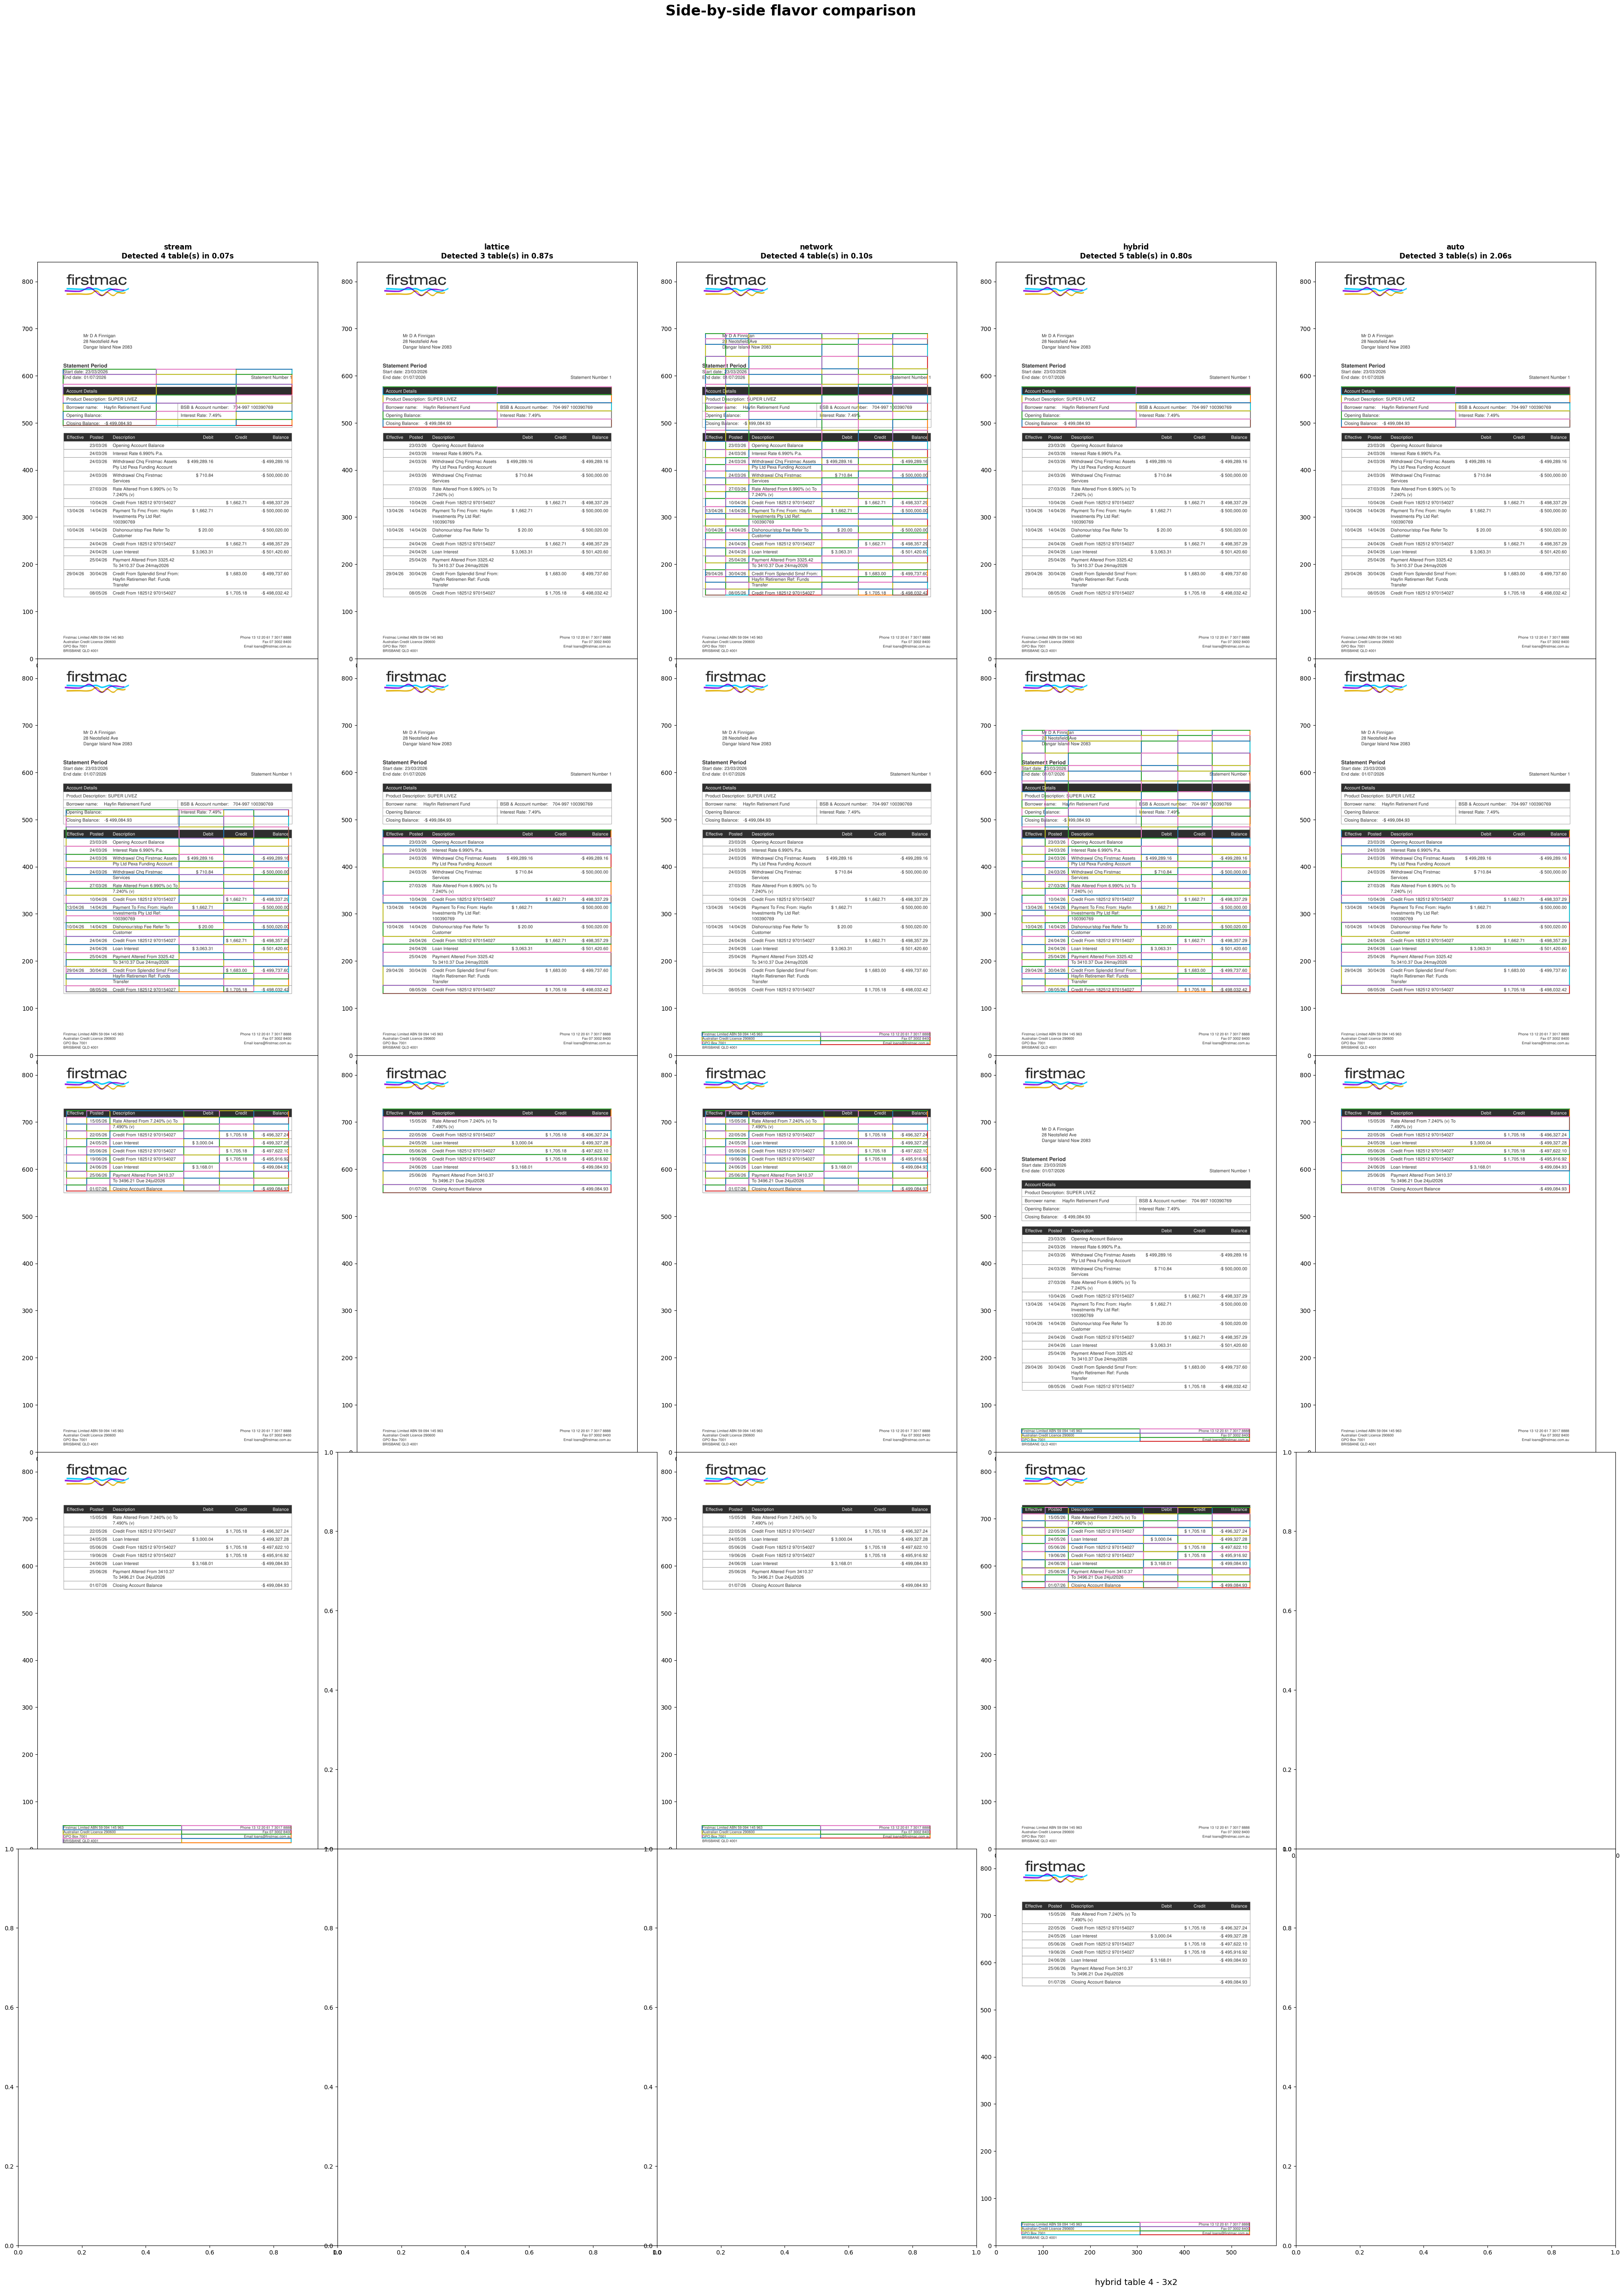

In [39]:
# Set up plotting options
import matplotlib.pyplot as plt

# %matplotlib inline
PLOT_HEIGHT = 12

row_count = max(max_tables, 1)
# Cap subplot grid width — 5 flavors at 12in each = 60in figure is unwieldy.
plt.rcParams["figure.figsize"] = [PLOT_HEIGHT * min(len(FLAVORS), 4), PLOT_HEIGHT * row_count]
fig, axes = plt.subplots(row_count, len(FLAVORS))
plt.subplots_adjust(wspace=0, hspace=0)  # Reduce margins to maximize the display zone

fig.suptitle("Side-by-side flavor comparison", fontsize=24, fontweight="bold")
for idx, flavor in enumerate(FLAVORS):
    parse = parses[flavor]
    tables = parse["tables"]
    top_ax = axes.flat[idx]
    title = f"{flavor}\n" f"Detected {len(tables)} table(s) in {parse['time']:.2f}s"
    if parse["error"]:
        title = title + f"\nError parsing: {parse['error']}"
    top_ax.set_title(title, fontsize=12, fontweight="bold")
    for table_idx, table in enumerate(tables):
        if max_tables > 1:
            ax = axes[table_idx][idx]
        else:
            ax = axes[idx]
        # Check if the table has data before attempting to plot it
        if (
            table.shape[0] > 0 and table.shape[1] > 0
        ):  # Check if table has rows and columns
            fig = camelot.plot(table, kind="grid", ax=ax)
            ax.text(
                0.5,
                -0.1,
                "{flavor} table {table_idx} - {rows}x{cols}".format(
                    flavor=flavor,
                    table_idx=table_idx,
                    rows=table.shape[0],
                    cols=table.shape[1],
                ),
                size=14,
                ha="center",
                transform=ax.transAxes,
            )
        else:
            print(
                f"Skipping plotting for empty table {table_idx} in {flavor}"
            )  # Inform user about the skipped table
        timer_after_plot = time.perf_counter()

## Line-detection engine: raster vs combined (lattice)

`flavor='lattice'` (and the lattice half of `flavor='hybrid'`) accept an
`engine=` option (#763):

- `'raster'` *(default)* — render the page and detect ruled lines with OpenCV.
- `'combined'` — run raster detection **and** union in the ruled lines read
  straight from the PDF's native vector graphics. This recovers tables whose
  rules render faintly (vector strokes / anti-aliasing) and is **never worse
  than `'raster'`** — raster always runs first, vector lines can only add.
- `'auto'` — use `'combined'` when the page carries vector ruled lines, else
  `'raster'`.

The cell below parses the selected PDF with both engines so you can compare
table counts and accuracy. On a crisply-ruled PDF the two are identical; the
difference shows up on faintly-ruled vector tables.

In [41]:
# Compare the raster and combined line-detection engines on the lattice parser.
for engine in ["raster", "combined"]:
    timer = time.perf_counter()
    try:
        tables = camelot.read_pdf(
            filename, flavor="hybrid", pages="all", engine=engine, **kwargs
        )
    except Exception as exc:  # noqa: BLE001 - demo: surface any parse error
        print(f"engine={engine}: error: {exc}")
        continue
    elapsed = time.perf_counter() - timer
    print(f"##### engine={engine}: {tables.n} table(s) in {elapsed:.2f}s #####")
    for idx, table in enumerate(tables):
        report = table.parsing_report
        print(
            f"## table {idx}: accuracy={report.get('accuracy', 0):.1f}% "
            f"whitespace={report.get('whitespace', 0):.1f}% ##"
        )
        display(table.df)

/tmp/ipykernel_641/1997997122.py:5: UserWarning: camelot.read_pdf: auto-detected per-page flavors {1: 'lattice', 2: 'lattice'}
  tables = camelot.read_pdf(


##### engine=raster: 3 table(s) in 2.47s #####
## table 0: accuracy=100.0% whitespace=0.0% ##


,0
0,Account Details
1,Product Description: SUPER LIVEZ
2,Borrower name:\nHayfin Retirement Fund\nBSB & ...
3,Opening Balance:\nInterest Rate: 7.49%
4,"Closing Balance:\n-$ 499,084.93"


## table 1: accuracy=100.0% whitespace=0.0% ##


,0
0,Effective\nPosted\nDescription\nDebit\nCredit\...
1,23/03/26\nOpening Account Balance
2,24/03/26\nInterest Rate 6.990% P.a.
3,24/03/26\nWithdrawal Chq Firstmac Assets\n$ 49...
4,24/03/26\nWithdrawal Chq Firstmac\n$ 710.84\n-...
5,27/03/26\nRate Altered From 6.990% (v) To\n7.2...
6,"10/04/26\nCredit From 182512 970154027\n$ 1,66..."
7,"$ 1,662.71\n-$ 500,000.00\n13/04/26\n14/04/26\..."
8,10/04/26\n14/04/26\nDishonour/stop Fee Refer T...
9,"24/04/26\nCredit From 182512 970154027\n$ 1,66..."


...

,0,1
0,Account Details,
1,Product Description: SUPER LIVEZ,
2,Borrower name:\nHayfin Retirement Fund,BSB & Account number:\n704-997 100390769
3,Opening Balance:,Interest Rate: 7.49%
4,"Closing Balance:\n-$ 499,084.93",


## table 1: accuracy=100.0% whitespace=0.0% ##


,0
0,Effective\nPosted\nDescription\nDebit\nCredit\...
1,23/03/26\nOpening Account Balance
2,24/03/26\nInterest Rate 6.990% P.a.
3,24/03/26\nWithdrawal Chq Firstmac Assets\n$ 49...
4,24/03/26\nWithdrawal Chq Firstmac\n$ 710.84\n-...
5,27/03/26\nRate Altered From 6.990% (v) To\n7.2...
6,"10/04/26\nCredit From 182512 970154027\n$ 1,66..."
7,"$ 1,662.71\n-$ 500,000.00\n13/04/26\n14/04/26\..."
8,10/04/26\n14/04/26\nDishonour/stop Fee Refer T...
9,"24/04/26\nCredit From 182512 970154027\n$ 1,66..."


## table 2: accuracy=100.0% whitespace=0.0% ##


,0
0,Effective\nPosted\nDescription\nDebit\nCredit\...
1,15/05/26\nRate Altered From 7.240% (v) To\n7.4...
2,"22/05/26\nCredit From 182512 970154027\n$ 1,70..."
3,"24/05/26\nLoan Interest\n$ 3,000.04\n-$ 499,32..."
4,"05/06/26\nCredit From 182512 970154027\n$ 1,70..."
5,"19/06/26\nCredit From 182512 970154027\n$ 1,70..."
6,"24/06/26\nLoan Interest\n$ 3,168.01\n-$ 499,08..."
7,25/06/26\nPayment Altered From 3410.37\nTo 349...
8,"01/07/26\nClosing Account Balance\n-$ 499,084.93"
